В этом ноутбуке реализована классификации трёхкомпонентных систем с помощью UniMol. Ниже последовательно идут: загрузка данных, подготовка молекул в формат UniMol, описание модели, двухстадийное обучение, подбор порога. 


In [ ]:
from unimol_tools.data import Dictionary
from unimol_tools.data.conformer import ConformerGen, coords2unimol
from unimol_tools.models import UniMolModel
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt
from IPython.display import clear_output


In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


### Загрузка данных
Основной датасет делится на трейн и тест

`sulf` - дополнительный тестовый датасет с сильным domain shift


In [3]:
df = pd.read_pickle('final/triple_real_xtb.pkl')
print(df.shape[0])
df.head(2)

192647


,source_file,formula_1,xyz_1_3d,formula_2,xyz_2_3d,formula_3,xyz_3_3d,xtb_1_3d,xtb_2_3d,xtb_3_3d,xtb_concat_3d,cryst
0,GATCAH,GdC46N6(ClO4)2,126\nGd2 C92 N12 Cl4 O16\nC -1.911545 2.376586...,C3NO,5\nC3 N1 O1\nC -0.400809 -0.551343 -0.789440\n...,ClO4,5\nCl1 O4\nO -1.098584 0.802731 0.395786\nO -0...,"[1.0, 1.0, -314.9685994404997, 126.0, -2.49975...","[1.0, 1.0, -13.22904652994901, 5.0, -2.6458093...","[1.0, 1.0, -20.39468970230421, 5.0, -4.0789379...","[1.0, 1.0, -314.9686, 126.0, -2.4997509, 7.076...",1
1,ZESSUL,EuC24(N2O3)2,70\nEu2 C48 N8 O12\nO 0.797972 1.673834 -0.006...,C5N,12\nC10 N2\nC -2.795876 -0.601193 0.610952\nC ...,ClO4,5\nCl1 O4\nO 1.375560 -0.122040 0.309645\nO -0...,"[1.0, 1.0, -175.22370355489122, 70.0, -2.50319...","[1.0, 1.0, -26.738125111357956, 12.0, -2.22817...","[1.0, 1.0, -20.394692431724913, 5.0, -4.078938...","[1.0, 1.0, -175.22371, 70.0, -2.5031958, 4.955...",1


In [5]:
sulf_df  = pd.read_pickle('final/sulf_rebuilt_xtb.pkl')
print(sulf_df.shape[0])
sulf_df.head(2)

85


,A,B,G,cryst,xyz_1_rebuilt,xyz_2_rebuilt,xyz_3_rebuilt,xtb_1_rebuilt,xtb_2_rebuilt,xtb_3_rebuilt,xtb_concat_rebuilt
0,[NH3+]C1=CC=C(OC2=CC=C([NH3+])C=C2)C=C1,CC1=CC=C(S(=O)(=O)[O-])C=C1,CC1=CC(C)=C(O)C=C1,1,15\n\nN -2.736585 3.146700 -0.842205\nC -1.866...,11\n\nC -1.581266 -0.695319 1.971559\nC -0.737...,9\n\nC -0.321045 -0.211138 -3.289374\nC -0.353...,"[1.0, 1.0, -35.05280903585239, 15.0, -2.336853...","[1.0, 1.0, -29.881285250719998, 11.0, -2.71648...","[1.0, 1.0, -20.76658446705264, 9.0, -2.3073982...","[1.0, 1.0, -35.05280903585239, 15.0, -2.336853..."
1,[NH3+]C1=CC=C(OC2=CC=C([NH3+])C=C2)C=C1,CC1=CC=C(S(=O)(=O)[O-])C=C1,CCC1=C(O)C=CC=C1,1,15\n\nN -2.779333 3.134391 -0.757041\nC -1.905...,11\n\nC -1.581266 -0.695319 1.971559\nC -0.737...,9\n\nC 0.725632 1.341181 -5.871308\nC 0.614510...,"[1.0, 1.0, -35.05280699650334, 15.0, -2.336853...","[1.0, 1.0, -29.881285250722144, 11.0, -2.71648...","[1.0, 1.0, -20.836285365916474, 9.0, -2.315142...","[1.0, 1.0, -35.05280699650334, 15.0, -2.336853..."


In [6]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['cryst']
)

train_inner_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['cryst']
)

print(train_inner_df.shape, val_df.shape, test_df.shape)

(123293, 12) (30824, 12) (38530, 12)


Инициализация словаря токенов UniMol


In [7]:
confgen = ConformerGen(
    data_type='molecule',
    remove_hs=True
)

dictionary = confgen.dictionary
pad_idx = dictionary.pad()

print('dictionary size:', len(dictionary))
print('pad_idx:', pad_idx)

dictionary size: 31
pad_idx: 2


Преобразование текстового `xyz`-представления в список атомов и массив 3D-координат. Это промежуточный шаг между сырыми строками в таблице и входом модели UniMol.


In [8]:
def parse_xyz_string(xyz_text):
    lines = [line.strip() for line in str(xyz_text).splitlines() if line.strip()]

    n_atoms = int(lines[0])
    atom_lines = lines[2:2 + n_atoms]

    atoms = []
    coordinates = []

    for line in atom_lines:
        parts = line.split()
        atom = parts[0]
        x, y, z = map(float, parts[1:4])

        atoms.append(atom)
        coordinates.append([x, y, z])

    return {
        'atoms': atoms,
        'coordinates': np.array(coordinates, dtype=np.float32)
    }

Преобразование молекулы в формат входа UniMol

In [9]:
def to_unimol_input(conf, dictionary, max_atoms=256, remove_hs=True):
    atoms = conf['atoms']
    coords = np.array(conf['coordinates'], dtype=np.float32)

    out = coords2unimol(
        atoms=atoms,
        coordinates=coords,
        dictionary=dictionary,
        max_atoms=max_atoms,
        remove_hs=remove_hs
    )
    return out

Подготовка одного объекта выборки: читает три молекулы из датафрейма, переводит каждую в UniMol input и возвращает тройку молекул вместе с бинарной меткой `cryst`.


In [10]:
class TripleUniMolDataset(Dataset):
    def __init__(self, df_part, dictionary, xyz_cols=('xyz_1_3d', 'xyz_2_3d', 'xyz_3_3d'), max_atoms=256, remove_hs=True):
        self.df = df_part.dropna(subset=list(xyz_cols)).reset_index(drop=True)
        self.dictionary = dictionary
        self.xyz_cols = xyz_cols
        self.max_atoms = max_atoms
        self.remove_hs = remove_hs

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        mol1 = to_unimol_input(
            parse_xyz_string(row[self.xyz_cols[0]]),
            self.dictionary,
            self.max_atoms,
            self.remove_hs
        )
        mol2 = to_unimol_input(
            parse_xyz_string(row[self.xyz_cols[1]]),
            self.dictionary,
            self.max_atoms,
            self.remove_hs
        )
        mol3 = to_unimol_input(
            parse_xyz_string(row[self.xyz_cols[2]]),
            self.dictionary,
            self.max_atoms,
            self.remove_hs
        )

        y = float(row['cryst'])

        return {
            'mol1': mol1,
            'mol2': mol2,
            'mol3': mol3,
            'y': y
        }

Функции паддинга для сборки батча из молекул разного размера

In [11]:
def pad_1d(arr_list, pad_value, dtype):
    max_len = max(len(x) for x in arr_list)
    batch = np.full((len(arr_list), max_len), pad_value, dtype=dtype)
    for i, x in enumerate(arr_list):
        batch[i, :len(x)] = x
    return batch

In [12]:
def pad_2d_square(arr_list, pad_value, dtype):
    max_len = max(x.shape[0] for x in arr_list)
    batch = np.full((len(arr_list), max_len, max_len), pad_value, dtype=dtype)
    for i, x in enumerate(arr_list):
        l = x.shape[0]
        batch[i, :l, :l] = x
    return batch

In [13]:
def pad_2d_coord(arr_list, pad_value, dtype):
    max_len = max(x.shape[0] for x in arr_list)
    batch = np.full((len(arr_list), max_len, 3), pad_value, dtype=dtype)
    for i, x in enumerate(arr_list):
        l = x.shape[0]
        batch[i, :l, :] = x
    return batch

Сборка батча для троек молекул в формате UniMol

In [14]:
def collate_single_mol(mol_list):
    src_tokens = [m['src_tokens'] for m in mol_list]
    src_distance = [m['src_distance'] for m in mol_list]
    src_coord = [m['src_coord'] for m in mol_list]
    src_edge_type = [m['src_edge_type'] for m in mol_list]

    batch = {
        'src_tokens': torch.tensor(pad_1d(src_tokens, pad_idx, np.int64), dtype=torch.long),
        'src_distance': torch.tensor(pad_2d_square(src_distance, 0.0, np.float32), dtype=torch.float32),
        'src_coord': torch.tensor(pad_2d_coord(src_coord, 0.0, np.float32), dtype=torch.float32),
        'src_edge_type': torch.tensor(pad_2d_square(src_edge_type, 0, np.int64), dtype=torch.long),
    }
    return batch

In [15]:
def triple_collate_fn(batch):
    mol1_batch = collate_single_mol([item['mol1'] for item in batch])
    mol2_batch = collate_single_mol([item['mol2'] for item in batch])
    mol3_batch = collate_single_mol([item['mol3'] for item in batch])
    y_batch = torch.tensor([item['y'] for item in batch], dtype=torch.float32)

    return mol1_batch, mol2_batch, mol3_batch, y_batch

DataLoaders

In [16]:
train_dataset = TripleUniMolDataset(
    train_inner_df,
    dictionary,
    xyz_cols=('xyz_1_3d', 'xyz_2_3d', 'xyz_3_3d')
)

val_dataset = TripleUniMolDataset(
    val_df,
    dictionary,
    xyz_cols=('xyz_1_3d', 'xyz_2_3d', 'xyz_3_3d')
)

test_dataset = TripleUniMolDataset(
    test_df,
    dictionary,
    xyz_cols=('xyz_1_3d', 'xyz_2_3d', 'xyz_3_3d')
)

In [17]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    collate_fn=triple_collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    collate_fn=triple_collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    collate_fn=triple_collate_fn
)

In [20]:
sulf_dataset = TripleUniMolDataset(
    sulf_df,
    dictionary,
    xyz_cols=('xyz_1_rebuilt', 'xyz_2_rebuilt', 'xyz_3_rebuilt')
)

sulf_loader = DataLoader(
    sulf_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    collate_fn=triple_collate_fn
)

Классификатор

In [21]:
class TripleUniMolClassifier(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()

        self.backbone = UniMolModel(
            data_type='molecule'
        )

        self.repr_dim = None
        self.head = None
        self.dropout = dropout

    def encode_one(self, batch_dict):
        out = self.backbone(
            src_tokens=batch_dict['src_tokens'],
            src_distance=batch_dict['src_distance'],
            src_coord=batch_dict['src_coord'],
            src_edge_type=batch_dict['src_edge_type'],
            return_repr=True
        )

        if not isinstance(out, torch.Tensor) or out.ndim != 2:
            raise RuntimeError(f'Unexpected backbone output: type={type(out)}, shape={getattr(out, "shape", None)}')

        z = out

        if self.repr_dim is None:
            self.repr_dim = z.shape[1]
            self.head = nn.Sequential(
                nn.Linear(self.repr_dim * 2, 512),
                nn.BatchNorm1d(512),
                nn.ReLU(),
                nn.Dropout(self.dropout),

                nn.Linear(512, 128),
                nn.ReLU(),
                nn.Dropout(self.dropout),

                nn.Linear(128, 1)
            ).to(z.device)

        return z

    def build_system_representation(self, z1, z2, z3):
        mol_pool = torch.stack([z1, z2, z3], dim=1).mean(dim=1)

        d12 = torch.abs(z1 - z2)
        d13 = torch.abs(z1 - z3)
        d23 = torch.abs(z2 - z3)
        pair_pool = torch.stack([d12, d13, d23], dim=1).mean(dim=1)

        x = torch.cat([mol_pool, pair_pool], dim=1)
        return x, mol_pool, pair_pool

    def forward(self, mol1, mol2, mol3):
        z1 = self.encode_one(mol1)
        z2 = self.encode_one(mol2)
        z3 = self.encode_one(mol3)

        x, _, _ = self.build_system_representation(z1, z2, z3)
        logits = self.head(x).squeeze(1)
        return logits


Инициализация модели и прогон одного батча, чтобы материализовать размер эмбеддинга UniMol и построить классификационную голову


In [22]:
model = TripleUniMolClassifier(dropout=0.3).to(device)

mol1_b, mol2_b, mol3_b, y_b = next(iter(train_loader))
mol1_b = {k: v.to(device) for k, v in mol1_b.items()}
mol2_b = {k: v.to(device) for k, v in mol2_b.items()}
mol3_b = {k: v.to(device) for k, v in mol3_b.items()}

with torch.no_grad():
    _ = model(mol1_b, mol2_b, mol3_b)

print('repr_dim:', model.repr_dim)
print(model.head)

2026-04-15 18:12:37 | unimol_tools/models/unimol.py | 167 | INFO | Uni-Mol Tools | Loading pretrained weights from /home/igic/miniconda3/envs/nastya_unimol/lib/python3.10/site-packages/unimol_tools/weights/mol_pre_all_h_220816.pt


repr_dim: 512
Sequential(
  (0): Linear(in_features=1024, out_features=512, bias=True)
  (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=512, out_features=128, bias=True)
  (5): ReLU()
  (6): Dropout(p=0.3, inplace=False)
  (7): Linear(in_features=128, out_features=1, bias=True)
)


Учет дисбаланса классов

In [23]:
n_neg = (train_inner_df['cryst'].values == 0).sum()
n_pos = (train_inner_df['cryst'].values == 1).sum()
pos_weight = n_neg / n_pos

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=device)
)

print('n_neg:', n_neg)
print('n_pos:', n_pos)
print('pos_weight:', pos_weight)

n_neg: 119655
n_pos: 3638
pos_weight: 32.89032435404068


Функции для обучения

In [24]:
def set_trainable_stage(model, stage='head_only'):
    '''
    stage:
      - 'head_only'
      - 'head_last_layer'
    '''
    for p in model.backbone.parameters():
        p.requires_grad = False

    for p in model.head.parameters():
        p.requires_grad = True

    last_layer = model.backbone.encoder.layers[-1]

    if stage == 'head_last_layer':
        for p in last_layer.parameters():
            p.requires_grad = True

    return last_layer


def build_optimizer(model, stage, head_lr=1e-4, backbone_lr=1e-5, weight_decay=1e-4):
    last_layer = set_trainable_stage(model, stage=stage)

    if stage == 'head_only':
        optimizer = torch.optim.AdamW(
            model.head.parameters(),
            lr=head_lr,
            weight_decay=weight_decay
        )
    elif stage == 'head_last_layer':
        optimizer = torch.optim.AdamW([
            {'params': model.head.parameters(), 'lr': head_lr},
            {'params': last_layer.parameters(), 'lr': backbone_lr},
        ], weight_decay=weight_decay)
    else:
        raise ValueError(f'Unknown stage: {stage}')

    return optimizer


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for mol1, mol2, mol3, y in loader:
        mol1 = {k: v.to(device) for k, v in mol1.items()}
        mol2 = {k: v.to(device) for k, v in mol2.items()}
        mol3 = {k: v.to(device) for k, v in mol3.items()}
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(mol1, mol2, mol3)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * y.size(0)

    return total_loss / len(loader.dataset)


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_logits = []
    all_targets = []

    with torch.no_grad():
        for mol1, mol2, mol3, y in loader:
            mol1 = {k: v.to(device) for k, v in mol1.items()}
            mol2 = {k: v.to(device) for k, v in mol2.items()}
            mol3 = {k: v.to(device) for k, v in mol3.items()}
            y = y.to(device)

            logits = model(mol1, mol2, mol3)
            loss = criterion(logits, y)

            total_loss += loss.item() * y.size(0)
            all_logits.append(logits.cpu().numpy())
            all_targets.append(y.cpu().numpy())

    val_loss = total_loss / len(loader.dataset)
    all_logits = np.concatenate(all_logits)
    all_targets = np.concatenate(all_targets)
    probs = 1.0 / (1.0 + np.exp(-all_logits))

    val_ap = average_precision_score(all_targets, probs)
    val_roc = roc_auc_score(all_targets, probs)

    return val_loss, val_ap, val_roc


def run_stage(
    model,
    train_loader,
    val_loader,
    criterion,
    device,
    stage_name,
    optimizer,
    n_epochs,
    patience,
    scheduler=None,
    global_epoch_offset=0
):
    stage_history = []
    best_stage_val_roc_auc = -1
    best_stage_val_ap = -1
    best_stage_epoch = 0
    best_stage_model_state = None
    patience_counter = 0

    for epoch in range(n_epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_ap, val_roc = validate_one_epoch(model, val_loader, criterion, device)

        if scheduler is not None:
            scheduler.step(val_roc)

        global_epoch = global_epoch_offset + epoch + 1

        stage_history.append({
            'global_epoch': global_epoch,
            'stage_epoch': epoch + 1,
            'stage_name': stage_name,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_ap': val_ap,
            'val_roc_auc': val_roc,
        })

        if val_roc > best_stage_val_roc_auc:
            best_stage_val_roc_auc = val_roc
            best_stage_val_ap = val_ap
            best_stage_epoch = epoch + 1
            best_stage_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        clear_output(wait=True)
        print(f'Stage: {stage_name}')
        print(f'Epoch: {epoch + 1}/{n_epochs} | Global epoch: {global_epoch}')
        print(f'train_loss = {train_loss:.4f}')
        print(f'val_loss   = {val_loss:.4f}')
        print(f'val_AP     = {val_ap:.4f}')
        print(f'val_ROC_AUC= {val_roc:.4f}')
        print(f'best_stage_val_ROC_AUC = {best_stage_val_roc_auc:.4f}')
        print(f'best_stage_epoch       = {best_stage_epoch}')

        plt.figure(figsize=(8, 5))
        plt.plot([x['train_loss'] for x in stage_history], label='train_loss')
        plt.plot([x['val_loss'] for x in stage_history], label='val_loss')
        plt.xlabel('Epoch inside stage')
        plt.ylabel('Loss')
        plt.title(f'{stage_name}')
        plt.legend()
        plt.grid(True)
        plt.show()

        if patience_counter >= patience:
            print(f'Early stopping in stage "{stage_name}" at epoch {epoch + 1}')
            break

    return {
        'history': stage_history,
        'best_val_roc_auc': best_stage_val_roc_auc,
        'best_val_ap': best_stage_val_ap,
        'best_epoch': best_stage_epoch,
        'best_model_state': best_stage_model_state
    }


На первом этапе обучается только классификатор поверх замороженного UniMol энкодера. Чтобы немного адаптировать классификатор.


Stage: Stage 1 | head only
Epoch: 5/5 | Global epoch: 5
train_loss = 1.9609
val_loss   = 0.8920
val_AP     = 0.6567
val_ROC_AUC= 0.9596
best_stage_val_ROC_AUC = 0.9596
best_stage_epoch       = 5


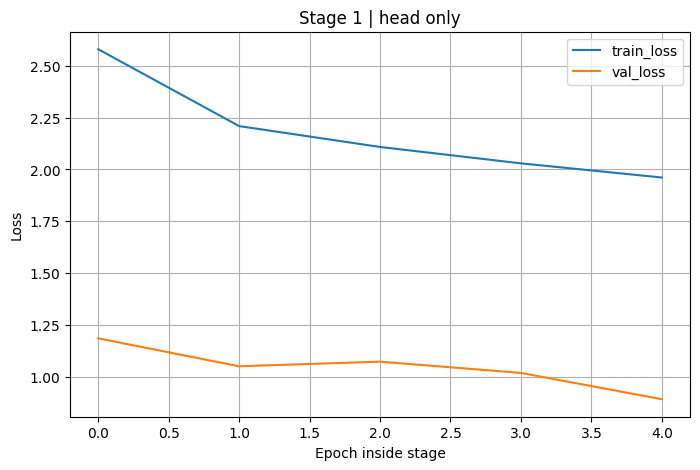

Stage 1 done
Best stage 1 val ROC-AUC: 0.9596001526491327
Best stage 1 val AP     : 0.6567144659135985
Best stage 1 epoch      : 5


In [ ]:
optimizer_stage1 = build_optimizer(
    model,
    stage='head_only',
    head_lr=1e-4,
    weight_decay=1e-4
)

scheduler_stage1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_stage1,
    mode='max',
    factor=0.5,
    patience=2
)

stage1_epochs = 5
stage1_patience = 3

stage1_results = run_stage(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    device=device,
    stage_name='Stage 1 | head only',
    optimizer=optimizer_stage1,
    n_epochs=stage1_epochs,
    patience=stage1_patience,
    scheduler=scheduler_stage1,
    global_epoch_offset=0
)

model.load_state_dict(stage1_results['best_model_state'])

print('Stage 1 done')
print('Best stage 1 val ROC-AUC:', stage1_results['best_val_roc_auc'])
print('Best stage 1 val AP     :', stage1_results['best_val_ap'])
print('Best stage 1 epoch      :', stage1_results['best_epoch'])


На втором этапе размораживается последний слой энкодера, и модель дообучается совместно с ним.

Stage: Stage 2 | head + last UniMol layer
Epoch: 15/15 | Global epoch: 20
train_loss = 1.0863
val_loss   = 0.7528
val_AP     = 0.7590
val_ROC_AUC= 0.9833
best_stage_val_ROC_AUC = 0.9833
best_stage_epoch       = 15


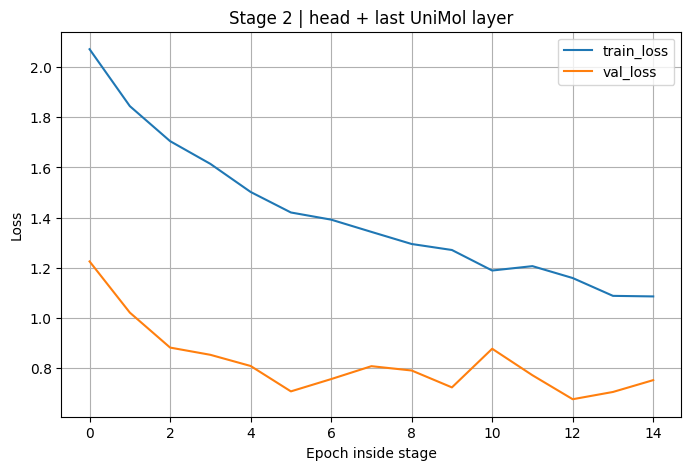

Stage 2 done
Best stage 2 val ROC-AUC: 0.9833117557189585
Best stage 2 val AP     : 0.7589512207040378
Best stage 2 epoch      : 15


In [ ]:
optimizer_stage2 = build_optimizer(
    model,
    stage='head_last_layer',
    head_lr=1e-4,
    backbone_lr=1e-5,
    weight_decay=1e-4
)

scheduler_stage2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_stage2,
    mode='max',
    factor=0.5,
    patience=2
)

stage2_epochs = 15
stage2_patience = 4

stage2_results = run_stage(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    device=device,
    stage_name='Stage 2 | head + last UniMol layer',
    optimizer=optimizer_stage2,
    n_epochs=stage2_epochs,
    patience=stage2_patience,
    scheduler=scheduler_stage2,
    global_epoch_offset=len(stage1_results['history'])
)

model.load_state_dict(stage2_results['best_model_state'])
model.eval()

print('Stage 2 done')
print('Best stage 2 val ROC-AUC:', stage2_results['best_val_roc_auc'])
print('Best stage 2 val AP     :', stage2_results['best_val_ap'])
print('Best stage 2 epoch      :', stage2_results['best_epoch'])


После двух стадий обучения выбирается чекпойнт с лучшим validation ROC-AUC.


Training done
Best stage: stage2
Best global epoch: 20
Best val ROC-AUC: 0.9833117557189585
Best val AP     : 0.7589512207040378


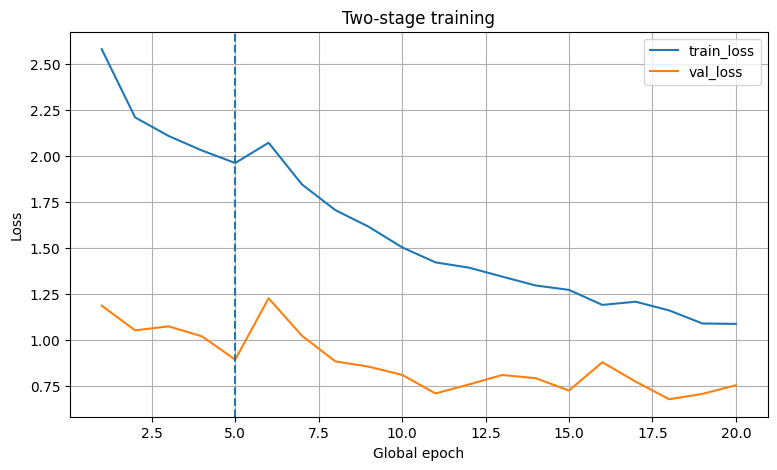

In [27]:
full_history = stage1_results['history'] + stage2_results['history']
history_df = pd.DataFrame(full_history)

train_losses = history_df['train_loss'].tolist()
val_losses = history_df['val_loss'].tolist()
val_ap_scores = history_df['val_ap'].tolist()
val_roc_scores = history_df['val_roc_auc'].tolist()

if stage1_results['best_val_roc_auc'] >= stage2_results['best_val_roc_auc']:
    best_model_state = copy.deepcopy(stage1_results['best_model_state'])
    best_val_roc_auc = float(stage1_results['best_val_roc_auc'])
    best_val_ap = float(stage1_results['best_val_ap'])
    best_epoch = int(stage1_results['best_epoch'])
    best_stage_name = 'stage1'
else:
    best_model_state = copy.deepcopy(stage2_results['best_model_state'])
    best_val_roc_auc = float(stage2_results['best_val_roc_auc'])
    best_val_ap = float(stage2_results['best_val_ap'])
    best_epoch = int(len(stage1_results['history']) + stage2_results['best_epoch'])
    best_stage_name = 'stage2'

print('Training done')
print('Best stage:', best_stage_name)
print('Best global epoch:', best_epoch)
print('Best val ROC-AUC:', best_val_roc_auc)
print('Best val AP     :', best_val_ap)

plt.figure(figsize=(9, 5))
plt.plot(history_df['global_epoch'], history_df['train_loss'], label='train_loss')
plt.plot(history_df['global_epoch'], history_df['val_loss'], label='val_loss')
plt.axvline(len(stage1_results['history']), linestyle='--')
plt.xlabel('Global epoch')
plt.ylabel('Loss')
plt.title('Two-stage training')
plt.legend()
plt.grid(True)
plt.show()


Подбор порога

Сначала загружается лучший чекпойнт, затем на validation-подвыборке подбирается рабочий threshold. В этом ноутбуке threshold оптимизируется по F-beta, чтобы контролировать компромисс между precision и recall.


In [ ]:
model.load_state_dict(best_model_state)
model.eval()

In [ ]:

def collect_probs_targets(model, loader, device):
    model.eval()

    all_logits = []
    all_targets = []

    with torch.no_grad():
        for mol1, mol2, mol3, y in loader:
            mol1 = {k: v.to(device) for k, v in mol1.items()}
            mol2 = {k: v.to(device) for k, v in mol2.items()}
            mol3 = {k: v.to(device) for k, v in mol3.items()}
            y = y.to(device)

            logits = model(mol1, mol2, mol3)

            all_logits.append(logits.detach().cpu().numpy())
            all_targets.append(y.detach().cpu().numpy())

    all_logits = np.concatenate(all_logits)
    all_targets = np.concatenate(all_targets)

    
    probs = np.where(
        all_logits >= 0,
        1.0 / (1.0 + np.exp(-all_logits)),
        np.exp(all_logits) / (1.0 + np.exp(all_logits))
    )

    return probs, all_targets


def find_best_threshold(y_true, probs, grid=None, beta=2.0):
    
    if grid is None:
        grid = np.linspace(0.05, 0.95, 181)

    best_threshold = 0.5
    best_fbeta = -1.0
    best_precision = 0.0
    best_recall = 0.0

    rows = []

    for thr in grid:
        preds = (probs >= thr).astype(int)

        fbeta = fbeta_score(y_true, preds, beta=beta, zero_division=0)
        precision = precision_score(y_true, preds, zero_division=0)
        recall = recall_score(y_true, preds, zero_division=0)

        rows.append({
            'threshold': float(thr),
            'f_beta': float(fbeta),
            'precision': float(precision),
            'recall': float(recall)
        })

        if (fbeta > best_fbeta) or (np.isclose(fbeta, best_fbeta) and recall > best_recall):
            best_threshold = float(thr)
            best_fbeta = float(fbeta)
            best_precision = float(precision)
            best_recall = float(recall)

    threshold_df = pd.DataFrame(rows)

    return best_threshold, best_fbeta, best_precision, best_recall, threshold_df


In [ ]:
val_probs, val_targets = collect_probs_targets(model, val_loader, device)

best_threshold, best_val_f2, best_val_precision, best_val_recall, threshold_df = find_best_threshold(
    val_targets,
    val_probs,
    beta=2.0
)

print(f'Best threshold on validation: {best_threshold:.4f}')
print(f'Validation F2 at best threshold: {best_val_f2:.4f}')
print(f'Validation Precision: {best_val_precision:.4f}')
print(f'Validation Recall: {best_val_recall:.4f}')

print('Training done')
print(f'Best epoch: {best_epoch}')
print(f'Best val ROC-AUC: {best_val_roc_auc:.4f}')
print(f'Best val AP     : {best_val_ap:.4f}')

Best threshold on validation: 0.9500
Validation F2 at best threshold: 0.7779
Validation Precision: 0.6102
Validation Recall: 0.8353
Training done
Best epoch: 20
Best val ROC-AUC: 0.9833
Best val AP     : 0.7590


## Evaluation

Ниже определена функция оценки, которая считает ROC-AUC, average precision, precision, recall и строит confusion matrix. Затем модель оценивается на `validation`, `test` и дополнительном наборе `sulf`.


In [29]:
def evaluate_loader(model, loader, title, threshold=0.5):
    model.eval()

    all_logits = []
    all_targets = []

    with torch.no_grad():
        for mol1, mol2, mol3, y in loader:
            mol1 = {k: v.to(device) for k, v in mol1.items()}
            mol2 = {k: v.to(device) for k, v in mol2.items()}
            mol3 = {k: v.to(device) for k, v in mol3.items()}

            logits = model(mol1, mol2, mol3)

            all_logits.append(logits.cpu().numpy())
            all_targets.append(y.numpy())

    all_logits = np.concatenate(all_logits)
    all_targets = np.concatenate(all_targets)

    probs = 1.0 / (1.0 + np.exp(-all_logits))
    preds = (probs >= threshold).astype(int)

    roc_auc = roc_auc_score(all_targets, probs)
    ap = average_precision_score(all_targets, probs)
    precision = precision_score(all_targets, preds, zero_division=0)
    recall = recall_score(all_targets, preds, zero_division=0)

    cm = confusion_matrix(all_targets, preds)

    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(
        f'{title}\nROC-AUC={roc_auc:.4f} | AP={ap:.4f} | Precision={precision:.4f} | Recall={recall:.4f}'
    )
    plt.show()

    print(title)
    print(f'ROC-AUC  : {roc_auc:.4f}')
    print(f'AP       : {ap:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall   : {recall:.4f}')

    return {
        'roc_auc': roc_auc,
        'ap': ap,
        'precision': precision,
        'recall': recall,
        'cm': cm,
        'probs': probs,
        'preds': preds,
    }

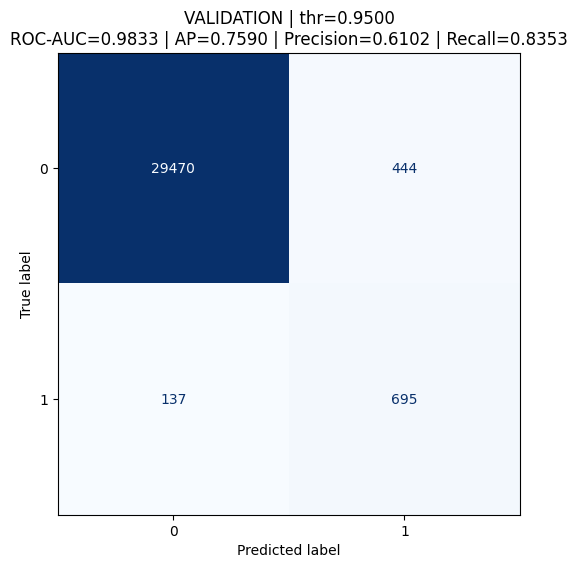

VALIDATION | thr=0.9500
ROC-AUC  : 0.9833
AP       : 0.7590
Precision: 0.6102
Recall   : 0.8353


In [30]:
results_val = evaluate_loader(
    model,
    val_loader,
    title=f'VALIDATION | thr={best_threshold:.4f}',
    threshold=best_threshold
)

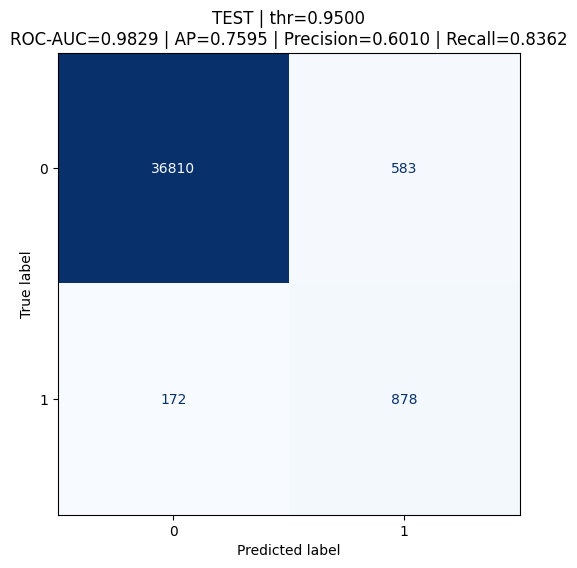

TEST | thr=0.9500
ROC-AUC  : 0.9829
AP       : 0.7595
Precision: 0.6010
Recall   : 0.8362


In [31]:
results_test = evaluate_loader(
    model,
    test_loader,
    title=f'TEST | thr={best_threshold:.4f}',
    threshold=best_threshold
)

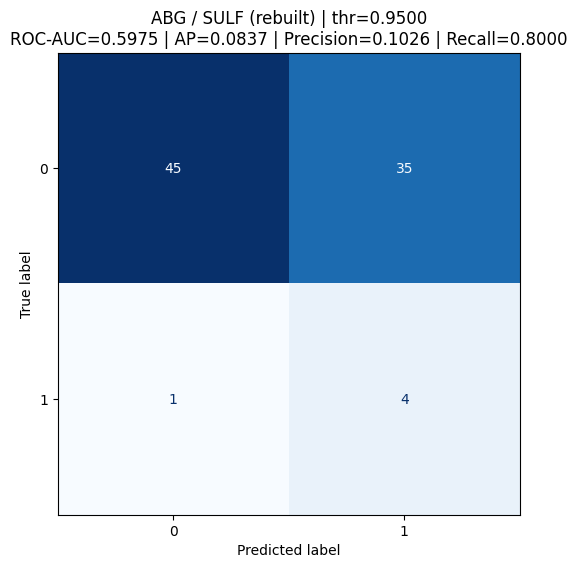

ABG / SULF (rebuilt) | thr=0.9500
ROC-AUC  : 0.5975
AP       : 0.0837
Precision: 0.1026
Recall   : 0.8000


In [32]:
results_abg = evaluate_loader(
    model,
    sulf_loader,
    title=f'ABG / SULF (rebuilt) | thr={best_threshold:.4f}',
    threshold=best_threshold
)